### Phase 1 – Chemnitz Data Acquisition & Initial EDA
#### Notebook: notebooks/phase1_data_acquisition.ipynb

This script fetches air quality and weather data for Chemnitz, Germany, and performs initial exploratory data analysis.



In [3]:
from dotenv import load_dotenv
import os, requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime, timedelta
import numpy as np
import datetime as dt


In [4]:
# API Keys & Configurations
# Load .env for API key
load_dotenv()
OPENAQ_API_KEY = os.getenv("OPENAQ_API_KEY")
headers = {"X-API-Key": OPENAQ_API_KEY}

In [5]:
# Setup Directories
Path("data/raw").mkdir(parents=True, exist_ok=True)
Path("data/processed").mkdir(parents=True, exist_ok=True)

In [6]:
print("="*60)
print("PHASE 1: CHEMNITZ DATA ACQUISITION")
print("="*60)

PHASE 1: CHEMNITZ DATA ACQUISITION


In [50]:
# Date range: last 90 days (UTC)
today = dt.datetime.now(dt.timezone.utc).date()
date_from = (today - dt.timedelta(days=90)).isoformat()
date_to = today.isoformat()
print(f"Date range: {date_from} to {date_to}")

Date range: 2025-11-03 to 2026-02-01



#### 1. Get locations near Chemnitz (documentation step)


In [8]:
print("\n[1] Fetching OpenAQ locations near Chemnitz (for info)...")


[1] Fetching OpenAQ locations near Chemnitz (for info)...


In [9]:
CHEMNITZ_LAT, CHEMNITZ_LON  = 50.79, 12.87  # Chemnitz
locations_url = "https://api.openaq.org/v3/locations"

params = {
    "coordinates": f"{CHEMNITZ_LAT},{CHEMNITZ_LON}",
    "radius": 20000,      # 20 km around Chemnitz
    "country": "DE",
    "limit": 50,
}

In [10]:
r = requests.get(locations_url, params=params, headers=headers)
print("Status:", r.status_code)
loc_json = r.json()
loc_df = pd.json_normalize(loc_json["results"])

#loc_df[["id", "name", "locality", "country"]].head()

Status: 200


In [11]:
loc_df.head()

,id,name,locality,timezone,isMobile,isMonitor,instruments,sensors,licenses,bounds,...,owner.id,owner.name,provider.id,provider.name,coordinates.latitude,coordinates.longitude,datetimeFirst.utc,datetimeFirst.local,datetimeLast.utc,datetimeLast.local
0,2932,Chemnitz Hans-Link-Stra�e,None,Europe/Berlin,False,True,"[{'id': 2, 'name': 'Government Monitor'}]","[{'id': 6227, 'name': 'no2 µg/m³', 'parameter'...","[{'id': 10, 'name': 'ODC-BY', 'attribution': {...","[12.917336000000002, 50.832461, 12.91733600000...",...,4,Unknown Governmental Organization,181,EEA Germany,50.832461,12.917336,2016-11-21T11:00:00Z,2016-11-21T12:00:00+01:00,2017-07-20T18:00:00Z,2017-07-20T20:00:00+02:00
1,4469,Chemnitz-Leipziger Str.,Chemnitz,Europe/Berlin,False,True,"[{'id': 2, 'name': 'Government Monitor'}]","[{'id': 4274678, 'name': 'no µg/m³', 'paramete...","[{'id': 10, 'name': 'ODC-BY', 'attribution': {...","[12.903367000370736, 50.84573999980416, 12.903...",...,4,Unknown Governmental Organization,70,EEA,50.845740,12.903367,2016-11-21T11:00:00Z,2016-11-21T12:00:00+01:00,2026-02-01T18:00:00Z,2026-02-01T19:00:00+01:00
2,2162224,Chemnitz Hans-Link-Straße,Chemnitz,Europe/Berlin,False,True,"[{'id': 2, 'name': 'Government Monitor'}]","[{'id': 7773165, 'name': 'no µg/m³', 'paramete...","[{'id': 10, 'name': 'ODC-BY', 'attribution': {...","[12.959368000335575, 50.85519000022021, 12.959...",...,4,Unknown Governmental Organization,70,EEA,50.855190,12.959368,2024-01-28T23:00:00Z,2024-01-29T00:00:00+01:00,2026-02-01T18:00:00Z,2026-02-01T19:00:00+01:00


In [12]:
loc_df.columns.value_counts

<bound method IndexOpsMixin.value_counts of Index(['id', 'name', 'locality', 'timezone', 'isMobile', 'isMonitor',
       'instruments', 'sensors', 'licenses', 'bounds', 'distance',
       'country.id', 'country.code', 'country.name', 'owner.id', 'owner.name',
       'provider.id', 'provider.name', 'coordinates.latitude',
       'coordinates.longitude', 'datetimeFirst.utc', 'datetimeFirst.local',
       'datetimeLast.utc', 'datetimeLast.local'],
      dtype='object')>

In [13]:
loc_clean = loc_df.drop(columns=['datetimeLast.utc', 'datetimeFirst.utc', 'provider.name', 'provider.id','owner.name','owner.id','country.id', 'country.code','instruments', 'sensors', 'licenses', 'bounds','timezone'])

In [14]:
loc_df.head()

,id,name,locality,timezone,isMobile,isMonitor,instruments,sensors,licenses,bounds,...,owner.id,owner.name,provider.id,provider.name,coordinates.latitude,coordinates.longitude,datetimeFirst.utc,datetimeFirst.local,datetimeLast.utc,datetimeLast.local
0,2932,Chemnitz Hans-Link-Stra�e,None,Europe/Berlin,False,True,"[{'id': 2, 'name': 'Government Monitor'}]","[{'id': 6227, 'name': 'no2 µg/m³', 'parameter'...","[{'id': 10, 'name': 'ODC-BY', 'attribution': {...","[12.917336000000002, 50.832461, 12.91733600000...",...,4,Unknown Governmental Organization,181,EEA Germany,50.832461,12.917336,2016-11-21T11:00:00Z,2016-11-21T12:00:00+01:00,2017-07-20T18:00:00Z,2017-07-20T20:00:00+02:00
1,4469,Chemnitz-Leipziger Str.,Chemnitz,Europe/Berlin,False,True,"[{'id': 2, 'name': 'Government Monitor'}]","[{'id': 4274678, 'name': 'no µg/m³', 'paramete...","[{'id': 10, 'name': 'ODC-BY', 'attribution': {...","[12.903367000370736, 50.84573999980416, 12.903...",...,4,Unknown Governmental Organization,70,EEA,50.845740,12.903367,2016-11-21T11:00:00Z,2016-11-21T12:00:00+01:00,2026-02-01T18:00:00Z,2026-02-01T19:00:00+01:00
2,2162224,Chemnitz Hans-Link-Straße,Chemnitz,Europe/Berlin,False,True,"[{'id': 2, 'name': 'Government Monitor'}]","[{'id': 7773165, 'name': 'no µg/m³', 'paramete...","[{'id': 10, 'name': 'ODC-BY', 'attribution': {...","[12.959368000335575, 50.85519000022021, 12.959...",...,4,Unknown Governmental Organization,70,EEA,50.855190,12.959368,2024-01-28T23:00:00Z,2024-01-29T00:00:00+01:00,2026-02-01T18:00:00Z,2026-02-01T19:00:00+01:00


In [15]:
chemnitz_locs = loc_clean[loc_clean["locality"].str.contains("Chemnitz", case=False, na=False)]
chemnitz_locs


,id,name,locality,isMobile,isMonitor,distance,country.name,coordinates.latitude,coordinates.longitude,datetimeFirst.local,datetimeLast.local
1,4469,Chemnitz-Leipziger Str.,Chemnitz,False,True,6631.667502,Germany,50.84574,12.903367,2016-11-21T12:00:00+01:00,2026-02-01T19:00:00+01:00
2,2162224,Chemnitz Hans-Link-Straße,Chemnitz,False,True,9604.607199,Germany,50.85519,12.959368,2024-01-29T00:00:00+01:00,2026-02-01T19:00:00+01:00


##### 2. Use known Chemnitz location and PM10 sensor

In [16]:
# Measurements Data Acquisition

location_id = 4469 #Chemnitz-Leipziger Str.
sensors_url = f"https://api.openaq.org/v3/locations/{location_id}/sensors"
r = requests.get(sensors_url, params={"limit":100}, headers=headers)
print("Status:", r.status_code)
sens_json = r.json()


Status: 200


In [17]:
sens_df = pd.json_normalize(sens_json["results"])
sens_df_cols = ["id", "name", "parameter.name", "parameter.units",
                "datetimeFirst.local", "datetimeLast.local"]
sens_df[sens_df_cols].head()

,id,name,parameter.name,parameter.units,datetimeFirst.local,datetimeLast.local
0,11057,pm10 µg/m³,pm10,µg/m³,2016-11-21T12:00:00+01:00,2026-02-01T19:00:00+01:00
1,11058,no2 µg/m³,no2,µg/m³,2016-11-21T12:00:00+01:00,2026-02-01T19:00:00+01:00
2,1312650,pm25 µg/m³,pm25,µg/m³,2021-06-05T02:00:00+02:00,2026-02-01T19:00:00+01:00
3,4274678,no µg/m³,no,µg/m³,2023-03-30T02:00:00+02:00,2024-03-11T12:00:00+01:00


In [59]:
sens_df[sens_df['parameter.name'] == 'pm10']

,id,name,parameter.id,parameter.name,parameter.units,parameter.displayName,datetimeFirst.utc,datetimeFirst.local,datetimeLast.utc,datetimeLast.local,...,latest.coordinates.longitude,summary.min,summary.q02,summary.q25,summary.median,summary.q75,summary.q98,summary.max,summary.avg,summary.sd
0,11057,pm10 µg/m³,1,pm10,µg/m³,PM10,2016-11-21T11:00:00Z,2016-11-21T12:00:00+01:00,2026-02-01T18:00:00Z,2026-02-01T19:00:00+01:00,...,12.903367,-1.0,None,None,None,None,None,616.797,15.962726,None


#### 3. Download PM10 measurements for that sensor

In [18]:
sensor_id = 11057
meas_url = f"https://api.openaq.org/v3/sensors/{sensor_id}/measurements"



params = {
    "datetime_from": f"{date_from}T00:00:00Z",
     "datetime_to": f"{date_to}T23:59:59Z",
    "limit": 1000,       # for more data you would paginate
}

meas_resp = requests.get(meas_url, params=params, headers=headers)
print("Status (measurements):", meas_resp.status_code)
print("URL:", meas_resp.url)



Status (measurements): 200
URL: https://api.openaq.org/v3/sensors/11057/measurements?datetime_from=2025-11-03T00%3A00%3A00Z&datetime_to=2026-02-01T23%3A59%3A59Z&limit=1000


In [19]:
if meas_resp.status_code != 200:
    print("Response snippet:")
    print(meas_resp.text[:500])
    raise RuntimeError("Failed to fetch measurements.")



In [20]:
meas_json = meas_resp.json()
meas_df = pd.json_normalize(meas_json["results"])

In [21]:
print("Columns:", meas_df.columns.tolist())


Columns: ['value', 'coordinates', 'summary', 'flagInfo.hasFlags', 'parameter.id', 'parameter.name', 'parameter.units', 'parameter.displayName', 'period.label', 'period.interval', 'period.datetimeFrom.utc', 'period.datetimeFrom.local', 'period.datetimeTo.utc', 'period.datetimeTo.local', 'coverage.expectedCount', 'coverage.expectedInterval', 'coverage.observedCount', 'coverage.observedInterval', 'coverage.percentComplete', 'coverage.percentCoverage', 'coverage.datetimeFrom.utc', 'coverage.datetimeFrom.local', 'coverage.datetimeTo.utc', 'coverage.datetimeTo.local']


In [22]:
meas_df.head()

,value,coordinates,summary,flagInfo.hasFlags,parameter.id,parameter.name,parameter.units,parameter.displayName,period.label,period.interval,...,coverage.expectedCount,coverage.expectedInterval,coverage.observedCount,coverage.observedInterval,coverage.percentComplete,coverage.percentCoverage,coverage.datetimeFrom.utc,coverage.datetimeFrom.local,coverage.datetimeTo.utc,coverage.datetimeTo.local
0,6.711,None,None,False,1,pm10,µg/m³,None,raw,01:00:00,...,1,01:00:00,1,01:00:00,100.0,100.0,2025-11-03T00:00:00Z,2025-11-03T01:00:00+01:00,2025-11-03T01:00:00Z,2025-11-03T02:00:00+01:00
1,3.683,None,None,False,1,pm10,µg/m³,None,raw,01:00:00,...,1,01:00:00,1,01:00:00,100.0,100.0,2025-11-03T01:00:00Z,2025-11-03T02:00:00+01:00,2025-11-03T02:00:00Z,2025-11-03T03:00:00+01:00
2,1.773,None,None,False,1,pm10,µg/m³,None,raw,01:00:00,...,1,01:00:00,1,01:00:00,100.0,100.0,2025-11-03T02:00:00Z,2025-11-03T03:00:00+01:00,2025-11-03T03:00:00Z,2025-11-03T04:00:00+01:00
3,4.527,None,None,False,1,pm10,µg/m³,None,raw,01:00:00,...,1,01:00:00,1,01:00:00,100.0,100.0,2025-11-03T03:00:00Z,2025-11-03T04:00:00+01:00,2025-11-03T04:00:00Z,2025-11-03T05:00:00+01:00
4,1.790,None,None,False,1,pm10,µg/m³,None,raw,01:00:00,...,1,01:00:00,1,01:00:00,100.0,100.0,2025-11-03T04:00:00Z,2025-11-03T05:00:00+01:00,2025-11-03T05:00:00Z,2025-11-03T06:00:00+01:00


In [23]:
# Save raw PM10 measurements
meas_path = Path("data/raw/openaq_chemnitz_pm10_90d.csv")
meas_df.to_csv(meas_path, index=False)
print(f"✓ Saved PM10 measurements to {meas_path} ({len(meas_df)} rows)")

✓ Saved PM10 measurements to data\raw\openaq_chemnitz_pm10_90d.csv (1000 rows)


#### 4. Download weather data from Open-Meteo

In [24]:
print("\n[4] Fetching weather data from Open-Meteo archive...")


[4] Fetching weather data from Open-Meteo archive...


In [25]:
weather_url = "https://archive-api.open-meteo.com/v1/archive"
weather_params = {
    "latitude": CHEMNITZ_LAT,
    "longitude": CHEMNITZ_LON,
    "start_date": date_from,
    "end_date": date_to,
    "hourly": "temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m",
    "timezone": "Europe/Berlin",
}

In [26]:
weather_resp = requests.get(weather_url, params=weather_params)
print("Status (weather):", weather_resp.status_code)
print("URL:", weather_resp.url)

Status (weather): 200
URL: https://archive-api.open-meteo.com/v1/archive?latitude=50.79&longitude=12.87&start_date=2025-11-03&end_date=2026-02-01&hourly=temperature_2m%2Crelative_humidity_2m%2Cprecipitation%2Cwind_speed_10m&timezone=Europe%2FBerlin


In [27]:
if weather_resp.status_code != 200:
    print("Response snippet:")
    print(weather_resp.text[:500])
    raise RuntimeError("Failed to fetch weather data.")

In [28]:
weather_json = weather_resp.json()
hourly = weather_json["hourly"]
#weather_df =pd.json_normalize(weather_json["hourly"])

In [29]:
weather_df = pd.DataFrame({
    "datetime": hourly["time"],
    "temperature_2m": hourly["temperature_2m"],
    "relative_humidity_2m": hourly["relative_humidity_2m"],
    "precipitation": hourly["precipitation"],
    "wind_speed_10m": hourly["wind_speed_10m"],
})

In [30]:
weather_df["datetime"] = pd.to_datetime(weather_df["datetime"])

In [ ]:
weather_path = Path("data/raw/openmeteo_chemnitz_weather_90d.csv")
weather_df.to_csv(weather_path, index=False)
print(f"✓ Saved weather data to {weather_path} ({len(weather_df)} rows)")

✓ Saved weather data to data\raw\openmeteo_chemnitz_weather_90d.csv (2184 rows)


#### 5. Quick info printout

In [32]:
print("\n[5] Summary")
print("-" * 60)
print(f"PM10 rows:    {len(meas_df)}")
if "datetime.local" in meas_df.columns:
    print(f"PM10 range:   {meas_df['datetime.local'].min()}  to  {meas_df['datetime.local'].max()}")
print(f"Weather rows: {len(weather_df)}")
print(f"Weather range:{weather_df['datetime'].min()}  to  {weather_df['datetime'].max()}")

print("\nDone. You now have real Chemnitz PM10 + weather data in data/raw/.")


[5] Summary
------------------------------------------------------------
PM10 rows:    1000
Weather rows: 2184
Weather range:2025-11-03 00:00:00  to  2026-02-01 23:00:00

Done. You now have real Chemnitz PM10 + weather data in data/raw/.


#### EDA on PM10 + weather


In [36]:
meas_df.columns

Index(['value', 'coordinates', 'summary', 'flagInfo.hasFlags', 'parameter.id',
       'parameter.name', 'parameter.units', 'parameter.displayName',
       'period.label', 'period.interval', 'period.datetimeFrom.utc',
       'period.datetimeFrom.local', 'period.datetimeTo.utc',
       'period.datetimeTo.local', 'coverage.expectedCount',
       'coverage.expectedInterval', 'coverage.observedCount',
       'coverage.observedInterval', 'coverage.percentComplete',
       'coverage.percentCoverage', 'coverage.datetimeFrom.utc',
       'coverage.datetimeFrom.local', 'coverage.datetimeTo.utc',
       'coverage.datetimeTo.local'],
      dtype='object')

In [54]:
meas_df = pd.read_csv("data/raw/openaq_chemnitz_pm10_90d.csv")

In [55]:
# Extract key columns
pm10 = meas_df[['period.datetimeTo.local', 'value','parameter.name']].copy()
pm10.columns = ['datetime','pm10','parameter']

In [56]:
# Convert to datetime and numeric

pm10['datetime'] = pd.to_datetime(pm10['datetime'])
pm10['pm10'] = pd.to_numeric(pm10['pm10'], errors='coerce')


In [57]:
print("Requested date range:")
print(f"  From: {date_from}")
print(f"  To: {date_to}")

print("\nActual data range in sensor measurements:")
print(f"  From: {pm10['datetime'].min()}")
print(f"  To: {pm10['datetime'].max()}")
print(f"  Total days: {(pm10['datetime'].max() - pm10['datetime'].min()).days}")


Requested date range:
  From: 2025-11-03
  To: 2026-02-01

Actual data range in sensor measurements:
  From: 2025-11-03 02:00:00+01:00
  To: 2025-12-22 14:00:00+01:00
  Total days: 49


In [43]:
# Remove rows with missing values

pm10.dropna(subset=['pm10'], inplace=True)
pm10 = pm10.sort_values('datetime').reset_index(drop=True)

In [45]:
print(f"PM10 data: {len(pm10)} rows")
print(f"Date range: {pm10['datetime'].min()} to {pm10['datetime'].max()}")
pm10.head()

PM10 data: 1000 rows
Date range: 2025-11-03 02:00:00+01:00 to 2025-12-22 14:00:00+01:00


,datetime,pm10,parameter
0,2025-11-03 02:00:00+01:00,6.711,pm10
1,2025-11-03 03:00:00+01:00,3.683,pm10
2,2025-11-03 04:00:00+01:00,1.773,pm10
3,2025-11-03 05:00:00+01:00,4.527,pm10
4,2025-11-03 06:00:00+01:00,1.790,pm10


In [46]:
# 1. Summary stats

pm10['pm10'].describe()

count    1000.000000
mean       16.199890
std         8.469541
min         1.745000
25%        10.342750
50%        15.163000
75%        20.928000
max        71.801000
Name: pm10, dtype: float64

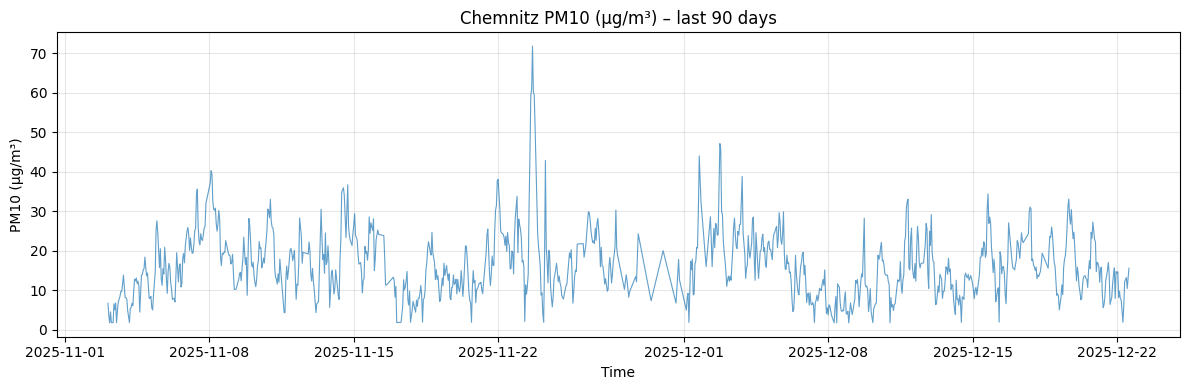

In [60]:
plt.figure(figsize=(12, 4))
plt.plot(pm10["datetime"], pm10["pm10"], alpha=0.7, linewidth=0.8)
plt.title("Chemnitz PM10 (µg/m³) – last 90 days")
plt.xlabel("Time")
plt.ylabel("PM10 (µg/m³)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("eda_pm10_timeseries.png", dpi=100)
plt.show()

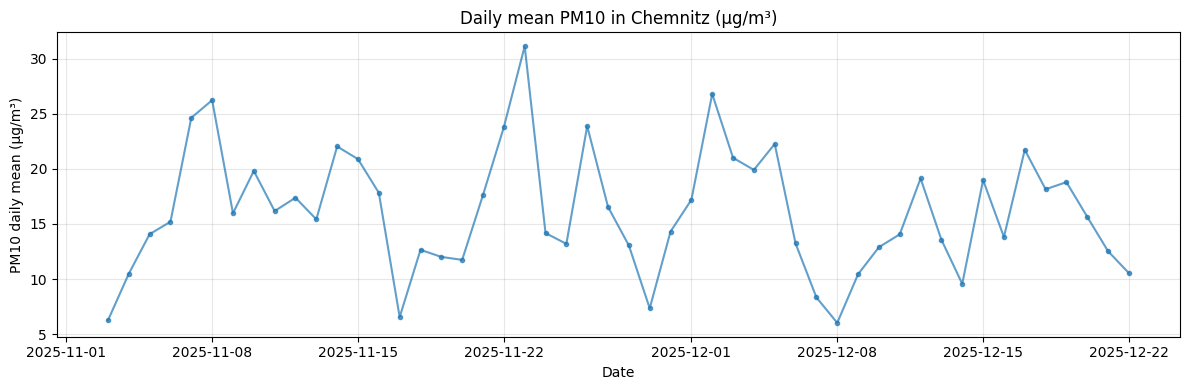

In [52]:
pm10_daily = (
    pm10.set_index("datetime")["pm10"]
        .resample("D")
        .mean()
        .reset_index()
        .rename(columns={"pm10": "pm10_daily_mean"})
)

plt.figure(figsize=(12, 4))
plt.plot(pm10_daily["datetime"], pm10_daily["pm10_daily_mean"], marker="o", markersize=3, alpha=0.7)
plt.title("Daily mean PM10 in Chemnitz (µg/m³)")
plt.xlabel("Date")
plt.ylabel("PM10 daily mean (µg/m³)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("eda_pm10_daily.png", dpi=100)
plt.show()

In [ ]:
# Load weather
weather_df = pd.read_csv("data/raw/openmeteo_chemnitz_weather_90d.csv")
weather_df["datetime"] = pd.to_datetime(weather_df["datetime"])

In [ ]:
# Round PM10 to hour for join
pm10_hourly = pm10.copy()
pm10_hourly["datetime"] = pm10_hourly["datetime"].dt.floor("H")
pm10_hourly = (
    pm10_hourly.groupby("datetime")["pm10"]
               .mean()
               .reset_index()
)


In [65]:
weather_df

,datetime,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
0,2025-11-03 00:00:00,8.4,95,0.4,13.9
1,2025-11-03 01:00:00,8.3,95,0.4,16.3
2,2025-11-03 02:00:00,8.1,96,0.9,17.3
3,2025-11-03 03:00:00,7.9,96,0.4,16.4
4,2025-11-03 04:00:00,7.5,94,0.2,21.1
...,...,...,...,...,...
2179,2026-02-01 19:00:00,-0.8,87,0.0,5.5
2180,2026-02-01 20:00:00,-0.6,86,0.0,7.2
2181,2026-02-01 21:00:00,-0.9,87,0.0,7.4
2182,2026-02-01 22:00:00,-1.4,87,0.0,7.1


In [73]:
# Merge
pm10_hourly["datetime"] = pm10_hourly["datetime"].dt.tz_localize(None)
pm10_weather = pd.merge(
    pm10_hourly,
    weather_df,
    on="datetime",
    how="inner"
)

In [74]:
print(f"Joined dataset: {len(pm10_weather)} rows")
pm10_weather.head()

Joined dataset: 1000 rows


,datetime,pm10,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
0,2025-11-03 02:00:00,6.711,8.1,96,0.9,17.3
1,2025-11-03 03:00:00,3.683,7.9,96,0.4,16.4
2,2025-11-03 04:00:00,1.773,7.5,94,0.2,21.1
3,2025-11-03 05:00:00,4.527,6.8,97,0.1,20.0
4,2025-11-03 06:00:00,1.790,6.2,96,0.1,18.3


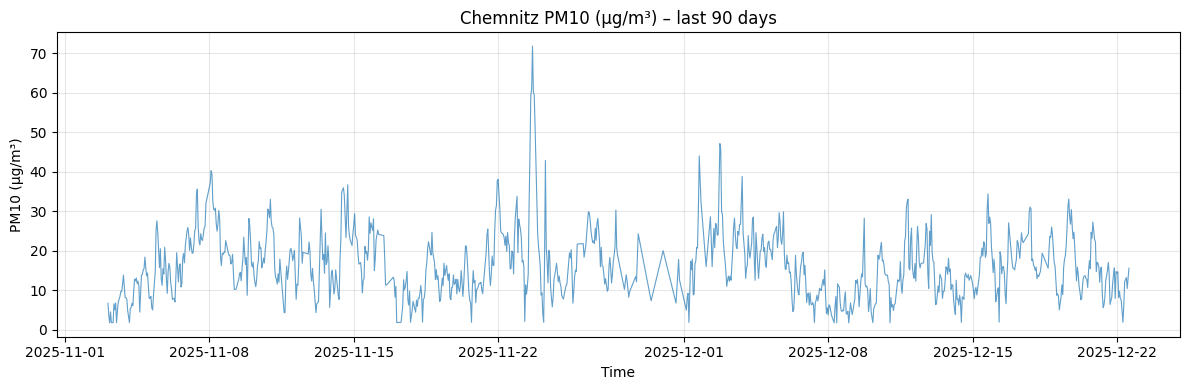

In [85]:
plt.figure(figsize=(12, 4))
plt.plot(pm10_weather["datetime"], pm10_weather["pm10"], alpha=0.7, linewidth=0.8)
plt.title("Chemnitz PM10 (µg/m³) – last 90 days")
plt.xlabel("Time")
plt.ylabel("PM10 (µg/m³)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("eda_pm10_timeseries.png", dpi=100)
plt.show()

In [86]:
weatheP10_path = Path("data/processed/chemnitz_pm10_weather_hourly.csv")
pm10_weather.to_csv(weatheP10_path, index=False)
print(f"✓ Saved weather data to {weatheP10_path} ({len(pm10_weather)} rows)")

✓ Saved weather data to data\processed\chemnitz_pm10_weather_hourly.csv (1000 rows)
